<a href="https://www.kaggle.com/code/sairam3999devineni/bakery-product-quality-classification-using-cnn?scriptVersionId=325262829" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Bakery Product Quality Classification Using CNN
## Phase 2 – Proposal, Code Development, and Technical Implementation

---

## 1. Project Title
**CNN-Based Bakery Product Quality Classification: Detecting Good vs. Bad Egg Bread Toast**

---

## 2. Background and Motivation
Food quality assurance is critical in the bakery industry. Manual inspection is time-consuming and inconsistent. CNN-based automated visual inspection offers a scalable, objective solution. This project classifies egg bread toast as **Good** or **Bad** based on visual cues like color, texture, and surface defects.

---

## 3. Problem Statement
Binary image classification: can a CNN reliably distinguish good-quality from bad-quality egg bread toast?

---

## 4. Dataset
- **Name:** Good and Bad Classification of Egg Bread Toast
- **Link:** https://www.kaggle.com/datasets/jocelyndumlao/good-and-bad-classification-of-egg-bread-toast

---

## 5. Dataset Description
| Property | Value |
|---|---|
| Total Images | 1,482 |
| Classes | 2 (`good egg bread`, `Bad egg bread`) |
| Good | 832 images |
| Bad | 650 images |
| Type | JPEG RGB |
| Imbalance | Mild (~56% / ~44%) |

---

## 6. Research Questions
- **RQ1:** How accurately can CNNs classify bakery product quality?
- **RQ2:** Custom CNN vs transfer learning – best performance/efficiency trade-off?
- **RQ3:** How do augmentation and class-weighting affect robustness?
- **RQ4:** Do Grad-CAM maps focus on meaningful quality regions?
- **RQ5:** What are the main failure modes and deployment limitations?

---

## 7–12. Methodology, Model Design, Transfer Learning, Metrics
**Methodology:** Load → Explore → Preprocess (224×224, normalise) → Augment → Split 70/15/15 → Train CNN → Fine-tune MobileNetV2 & EfficientNetB0 → Evaluate → Grad-CAM → Compare

**CNN:** 4× (Conv2D → BN → ReLU → MaxPool → Dropout) → GAP → Dense(256) → Dense(1, sigmoid)

**Transfer learning:** MobileNetV2 (last 30 layers unfrozen), EfficientNetB0 (last 20 layers unfrozen), both ImageNet weights

**Metrics:** Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC, Training curves, Inference time

---
# Code Implementation
---

## Section 1 – Install & Import Libraries

In [1]:
# ── Core imports ─────────────────────────────────────────────────────────────
import os, sys, random, time, warnings, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Suppress verbose TF/oneDNN info logs (keeps output clean)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPUs       : {len(tf.config.list_physical_devices("GPU"))}')

2026-06-07 21:59:40.844681: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780869581.264063      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780869581.387873      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780869582.443261      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780869582.443306      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780869582.443309      23 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
Keras      : 3.13.2
GPUs       : 2


## Section 2 – Configuration

In [2]:
# ── Auto-detect dataset root ──────────────────────────────────────────────────

def find_dataset_root() -> Path:
    """
    Scan /kaggle/input (all subdirs) for the folder containing
    both 'Bad egg bread' and 'good egg bread' subfolders.
    Falls back to current directory for local runs.
    """
    for base in [Path('/kaggle/input'), Path('.')]:
        if not base.exists():
            continue
        bad_hits  = list(base.rglob('Bad egg bread'))
        good_hits = list(base.rglob('good egg bread'))
        if bad_hits and good_hits:
            root = bad_hits[0].parent   # Parent of 'Bad egg bread' = data root
            print(f'[OK] Dataset root: {root}')
            return root
    raise FileNotFoundError(
        'Dataset not found.\n'
        'Kaggle: right panel → Add Input → jocelyndumlao/good-and-bad-classification-of-egg-bread-toast'
    )


DATASET_ROOT = find_dataset_root()

FOLDER_BAD  = 'Bad egg bread'
FOLDER_GOOD = 'good egg bread'
CLASS_NAMES = ['Bad', 'Good']   # 0=Bad, 1=Good

IMG_SIZE    = (224, 224)
INPUT_SHAPE = (224, 224, 3)

BATCH_SIZE    = 32
EPOCHS_CNN    = 30
EPOCHS_TL     = 20
LEARNING_RATE = 1e-4

TEST_RATIO = 0.15
VAL_RATIO  = 0.15

OUT_DIR = Path('/kaggle/working/outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('Configuration loaded successfully.')
print(f'Output directory: {OUT_DIR}')

[OK] Dataset root: /kaggle/input/datasets/sairam3999devineni/bakery-product-quality-classification/Good and Bad classification of  Egg Bread Toast
Configuration loaded successfully.
Output directory: /kaggle/working/outputs


## Section 3 – Dataset Loading & Exploration

In [3]:
# ── Load image paths into a DataFrame ────────────────────────────────────────

def load_image_paths(root: Path) -> pd.DataFrame:
    label_map = {FOLDER_BAD: 0, FOLDER_GOOD: 1}
    records   = []
    for folder, label in label_map.items():
        hits = list(root.rglob(folder))
        if not hits:
            print(f'[WARNING] Not found: {folder}')
            continue
        class_dir = hits[0]
        images    = (list(class_dir.glob('*.jpg'))  +
                     list(class_dir.glob('*.jpeg')) +
                     list(class_dir.glob('*.png')))
        for p in images:
            records.append({'filepath': str(p), 'label': label,
                            'class_name': 'Good' if label == 1 else 'Bad'})
        print(f'[OK] {len(images):>5} images in "{folder}"')
    if not records:
        raise ValueError('No images loaded. Check the dataset is attached.')
    return pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)


df = load_image_paths(DATASET_ROOT)
print(f'\nTotal: {len(df)} images')
print(df['class_name'].value_counts().to_string())
df.head()

[OK]   650 images in "Bad egg bread"
[OK]   832 images in "good egg bread"

Total: 1482 images
class_name
Good    832
Bad     650


,filepath,label,class_name
0,/kaggle/input/datasets/sairam3999devineni/bake...,0,Bad
1,/kaggle/input/datasets/sairam3999devineni/bake...,0,Bad
2,/kaggle/input/datasets/sairam3999devineni/bake...,1,Good
3,/kaggle/input/datasets/sairam3999devineni/bake...,0,Bad
4,/kaggle/input/datasets/sairam3999devineni/bake...,1,Good


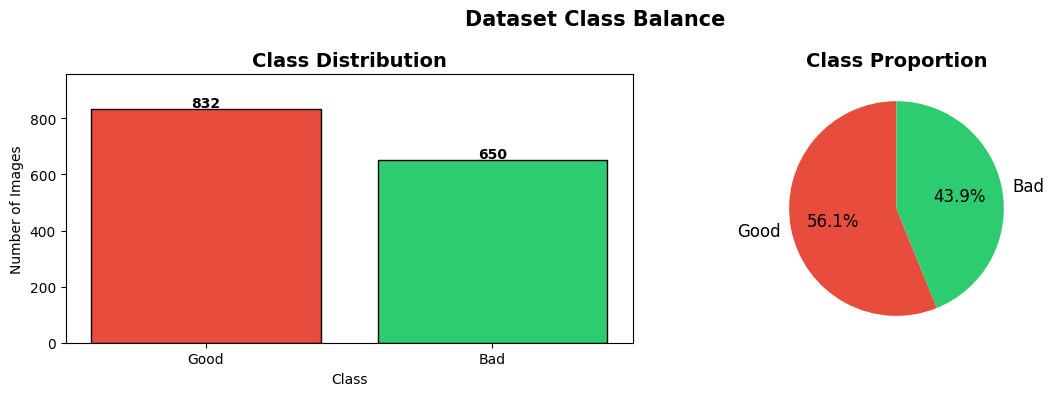

Saved: class_distribution.png


In [4]:
# ── Class distribution chart ──────────────────────────────────────────────────
counts = df['class_name'].value_counts()
colors = ['#e74c3c', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Number of Images')
axes[0].set_ylim(0, max(counts.values) * 1.15)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(cnt), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Class Balance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

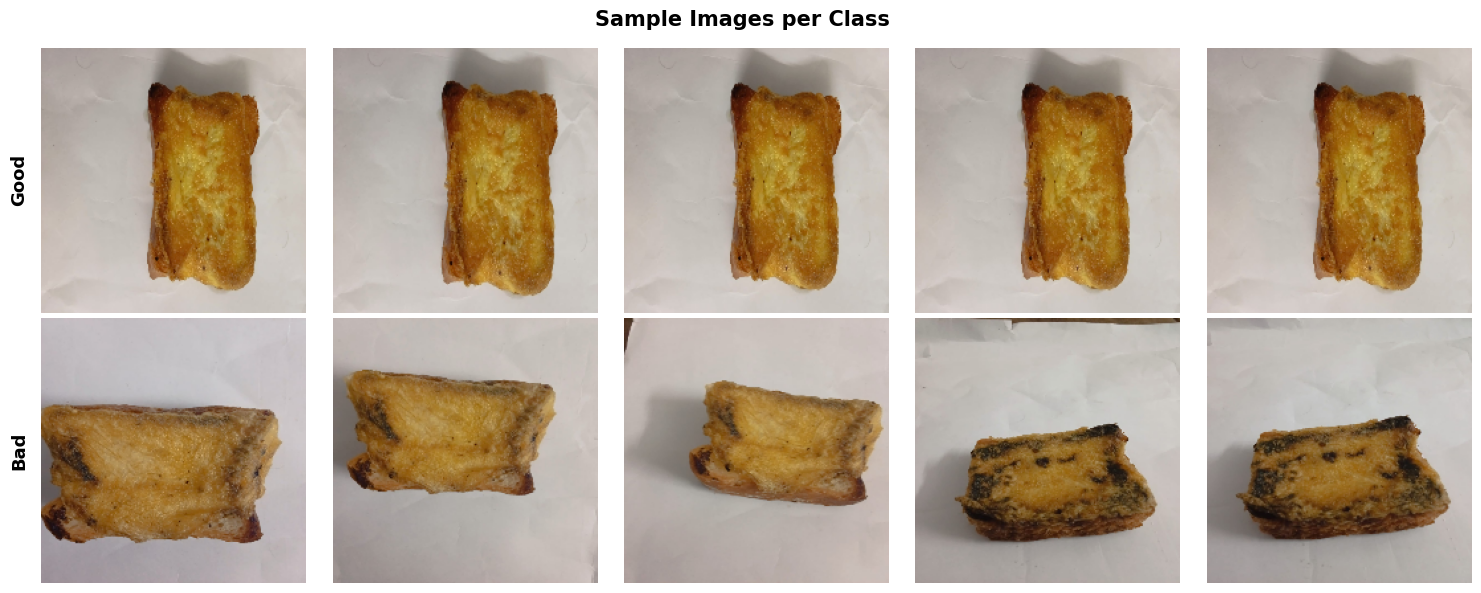

Saved: sample_images.png


In [5]:
# ── Sample image grid ─────────────────────────────────────────────────────────
N = 5
fig, axes = plt.subplots(2, N, figsize=(3*N, 6))
fig.suptitle('Sample Images per Class', fontsize=15, fontweight='bold')

for row, cls in enumerate(['Good', 'Bad']):
    subset = df[df['class_name'] == cls].sample(N, random_state=42)
    for col, (_, row_data) in enumerate(subset.iterrows()):
        img = cv2.imread(row_data['filepath'])
        ax  = axes[row, col]
        if img is None:
            ax.axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (200, 200))
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            # Use fig.text for class labels (works regardless of axis state)
            ax.text(-0.05, 0.5, cls, transform=ax.transAxes,
                    fontsize=13, fontweight='bold', va='center',
                    ha='right', rotation=90)

plt.tight_layout()
plt.savefig(OUT_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

## Section 4 – Data Splitting

In [6]:
# ── Stratified 70 / 15 / 15 split ────────────────────────────────────────────
X = df['filepath'].values
y = df['label'].values

X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, stratify=y, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=VAL_RATIO/(1-TEST_RATIO),
    stratify=y_tv, random_state=42)

print(f'Train : {len(X_train)} | Bad={sum(y_train==0)}, Good={sum(y_train==1)}')
print(f'Val   : {len(X_val)}  | Bad={sum(y_val==0)},  Good={sum(y_val==1)}')
print(f'Test  : {len(X_test)}  | Bad={sum(y_test==0)},  Good={sum(y_test==1)}')

Train : 1036 | Bad=454, Good=582
Val   : 223  | Bad=98,  Good=125
Test  : 223  | Bad=98,  Good=125


## Section 5 – Preprocessing & Data Augmentation

In [7]:
# ── tf.data pipeline with augmentation ───────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(filepath, label):
    raw = tf.io.read_file(filepath)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    return tf.clip_by_value(img, 0.0, 1.0), label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(1024, seed=42)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)

for imgs, lbls in train_ds.take(1):
    print(f'Batch shape : {imgs.shape}  dtype: {imgs.dtype}')
    print(f'Labels      : {lbls.numpy()[:8]}')
print('Datasets ready.')

I0000 00:00:1780869604.420485      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780869604.428943      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Batch shape : (32, 224, 224, 3)  dtype: <dtype: 'float32'>
Labels      : [0 1 1 0 0 1 1 1]
Datasets ready.


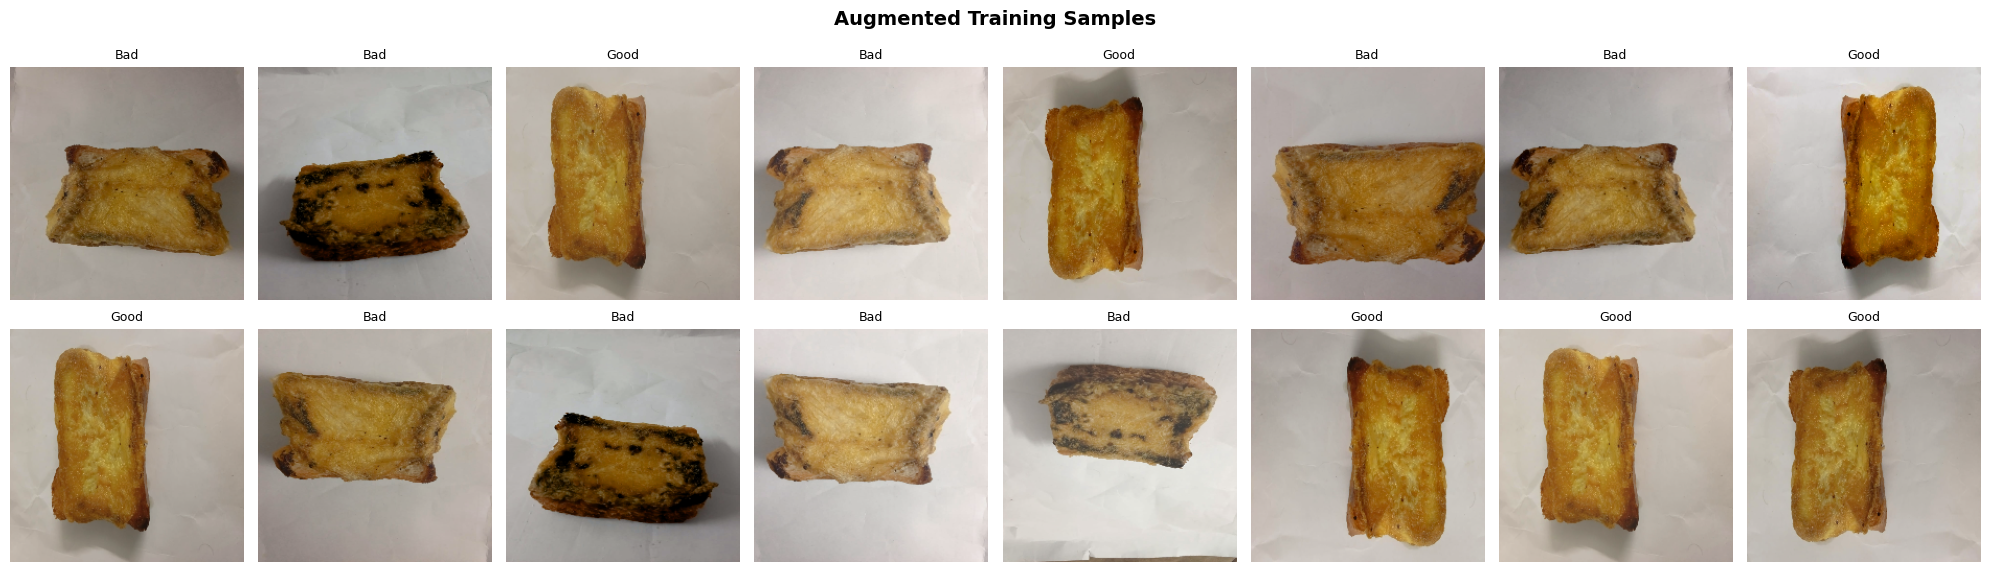

Saved: augmented_samples.png


In [8]:
# ── Visualise augmented samples ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Augmented Training Samples', fontsize=14, fontweight='bold')
batch_imgs, batch_lbls = next(iter(train_ds))
for i in range(8):
    for r in range(2):
        idx = i + r*8
        axes[r, i].imshow(batch_imgs[idx].numpy())
        axes[r, i].set_title(CLASS_NAMES[batch_lbls[idx].numpy()], fontsize=9)
        axes[r, i].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: augmented_samples.png')

## Section 6 – Model 1: Custom CNN

In [9]:
# ── Custom CNN (4-block architecture) ────────────────────────────────────────

def build_custom_cnn(input_shape=INPUT_SHAPE) -> keras.Model:
    """
    4-block CNN: Conv2D → BatchNorm → ReLU → MaxPool → Dropout (×4)
    Head: GlobalAveragePooling → Dense(256) → Dropout(0.5) → Dense(1, sigmoid)
    Random augmentation layers (Rotation, Zoom) are built in.
    """
    inp = keras.Input(shape=input_shape, name='cnn_input')
    x   = layers.RandomRotation(0.1)(inp)
    x   = layers.RandomZoom(0.1)(x)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.Dropout(0.25)(x)

    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid', name='cnn_output')(x)
    return keras.Model(inp, out, name='CustomCNN')


cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
cnn_model.summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 456,385 (1.74 MB)

 Trainable params: 455,425 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [10]:
# ── Train Custom CNN ──────────────────────────────────────────────────────────

# Class weights to handle mild imbalance
n_bad, n_good = sum(y_train==0), sum(y_train==1)
n_total       = len(y_train)
class_weight  = {0: n_total/(2*n_bad), 1: n_total/(2*n_good)}
print(f'Class weights → Bad: {class_weight[0]:.3f}  Good: {class_weight[1]:.3f}')

cnn_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint(str(OUT_DIR/'best_custom_cnn.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

t0 = time.time()
cnn_history = cnn_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_CNN, class_weight=class_weight,
    callbacks=cnn_callbacks, verbose=1
)
cnn_train_time = time.time() - t0
print(f'Custom CNN training time: {cnn_train_time:.0f}s')

Class weights → Bad: 1.141  Good: 0.890
Epoch 1/30


E0000 00:00:1780869624.002180      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CustomCNN_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780869629.048351      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.6554 - auc: 0.7134 - loss: 0.6261 - precision: 0.7370 - recall: 0.6457
Epoch 1: val_accuracy improved from None to 0.43946, saving model to /kaggle/working/outputs/best_custom_cnn.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_custom_cnn.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - accuracy: 0.7172 - auc: 0.7988 - loss: 0.5385 - precision: 0.7613 - recall: 0.7234 - val_accuracy: 0.4395 - val_auc: 0.5000 - val_loss: 0.6976 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8425 - auc: 0.9087 - loss: 0.3595 - precision: 0.8483 - recall: 0.8761
Epoch 2: val_accuracy did not improve from 0.43946
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - accuracy: 0.8456 - auc: 0.9195 - loss: 0.3428 - precision: 0.8528 - recall: 0.8763 - val_accuracy: 0.4395 - val_auc: 0.5000 - val_loss: 0.6967 - val_precision: 0.0000e+00 - val_r

## Section 7 – Internet Check for Transfer Learning Weights

> **⚠️ IMPORTANT — Enable Internet before running this cell:**
> Right panel → **Session options → Internet → ON**
>
> This is required to download ImageNet weights for MobileNetV2 and EfficientNetB0.
> Without it, transfer learning models will use random weights and produce poor results (~43% accuracy).
>
> **How to enable:**
> 1. Click the ⚙️ icon or go to **Settings** in the top menu
> 2. Toggle **Internet** to **ON**
> 3. Re-run from this cell onwards

In [11]:
# ── Internet connectivity check ───────────────────────────────────────────────

def check_internet(timeout=8):
    try:
        urllib.request.urlopen('https://storage.googleapis.com', timeout=timeout)
        return True
    except Exception:
        return False

INTERNET = check_internet()
TL_WEIGHTS = 'imagenet' if INTERNET else None

if INTERNET:
    print('✅ Internet ON  → TL_WEIGHTS = "imagenet"')
    print('   ImageNet weights will be downloaded automatically.')
else:
    print('❌ Internet OFF → TL_WEIGHTS = None')
    print('   Transfer learning models will use RANDOM weights — accuracy will be poor.')
    print('   Fix: Settings → Session options → Internet → ON  then re-run from here.')
    print()
    print('   NOTE: If you cannot enable internet, the notebook will still run')
    print('   but MobileNetV2/EfficientNetB0 results will not reflect true transfer learning.')

❌ Internet OFF → TL_WEIGHTS = None
   Transfer learning models will use RANDOM weights — accuracy will be poor.
   Fix: Settings → Session options → Internet → ON  then re-run from here.

   NOTE: If you cannot enable internet, the notebook will still run
   but MobileNetV2/EfficientNetB0 results will not reflect true transfer learning.


## Section 8 – Model 2: MobileNetV2 (Transfer Learning)

In [12]:
# ── MobileNetV2 ───────────────────────────────────────────────────────────────

def build_mobilenetv2(input_shape=INPUT_SHAPE, unfreeze_top=30):
    """
    MobileNetV2 pre-trained on ImageNet.
    Lower layers frozen; top `unfreeze_top` layers fine-tuned.
    Input rescaled from [0,1] to [-1,1] as expected by MobileNetV2.
    """
    base = MobileNetV2(weights=TL_WEIGHTS, include_top=False,
                       input_shape=input_shape)
    base.trainable = True
    for layer in base.layers[:-unfreeze_top]:
        layer.trainable = False

    inp = keras.Input(shape=input_shape, name='mnv2_input')
    x   = layers.Rescaling(scale=2.0, offset=-1.0)(inp)  # [0,1] → [-1,1]
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid', name='mnv2_output')(x)
    return keras.Model(inp, out, name='MobileNetV2')


mnv2_model = build_mobilenetv2()
mnv2_model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE/10),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
print(f'Weights : {TL_WEIGHTS}  |  Total params: {mnv2_model.count_params():,}')

mnv2_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(str(OUT_DIR/'best_mobilenetv2.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

t0 = time.time()
mnv2_history = mnv2_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_TL, class_weight=class_weight,
    callbacks=mnv2_callbacks, verbose=1
)
mnv2_train_time = time.time() - t0
print(f'MobileNetV2 training time: {mnv2_train_time:.0f}s')

Weights : None  |  Total params: 2,586,177
Epoch 1/20


I0000 00:00:1780869758.693998      74 service.cc:152] XLA service 0x20beb3e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780869758.694048      74 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780869758.694052      74 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-06-07 22:02:49.619002: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:02:49.756171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1780869774.430451      74 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the li

31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5078 - auc: 0.5090 - loss: 0.7220 - precision: 0.6719 - recall: 0.2861

2026-06-07 22:03:05.283342: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:03:05.419186: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.5088 - auc: 0.5092 - loss: 0.7214 - precision: 0.6683 - recall: 0.2938

2026-06-07 22:03:23.888029: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:03:24.027684: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:03:24.163949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from None to 0.43946, saving model to /kaggle/working/outputs/best_mobilenetv2.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_mobilenetv2.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5251 - auc: 0.5131 - loss: 0.7123 - precision: 0.6142 - recall: 0.4158 - val_accuracy: 0.4395 - val_auc: 0.5000 - val_loss: 0.6936 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5069 - auc: 0.5186 - loss: 0.7097 - precision: 0.5542 - recall: 0.5152
Epoch 2: val_accuracy did not improve from 0.43946
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.5222 - auc: 0.5327 - loss: 0.7014 - precision: 0.5822 - recall: 0.5292 - val_accuracy: 0.4395 - val_auc: 0.5000 - val_loss: 0.6943 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 3/20
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4991 - auc: 0.5103

## Section 9 – Model 3: EfficientNetB0 (Transfer Learning)

In [13]:
# ── EfficientNetB0 ────────────────────────────────────────────────────────────

def build_efficientnetb0(input_shape=INPUT_SHAPE, unfreeze_top=20):
    """
    EfficientNetB0 pre-trained on ImageNet.
    Input rescaled from [0,1] to [0,255] as expected by EfficientNet.
    """
    base = EfficientNetB0(weights=TL_WEIGHTS, include_top=False,
                          input_shape=input_shape)
    base.trainable = True
    for layer in base.layers[:-unfreeze_top]:
        layer.trainable = False

    inp = keras.Input(shape=input_shape, name='effnet_input')
    x   = layers.Rescaling(scale=255.0)(inp)     # [0,1] → [0,255]
    x   = base(x, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid', name='effnet_output')(x)
    return keras.Model(inp, out, name='EfficientNetB0')


effnet_model = build_efficientnetb0()
effnet_model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE/10),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)
print(f'Weights : {TL_WEIGHTS}  |  Total params: {effnet_model.count_params():,}')

effnet_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(str(OUT_DIR/'best_efficientnetb0.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

t0 = time.time()
effnet_history = effnet_model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_TL, class_weight=class_weight,
    callbacks=effnet_callbacks, verbose=1
)
effnet_train_time = time.time() - t0
print(f'EfficientNetB0 training time: {effnet_train_time:.0f}s')

Weights : None  |  Total params: 4,377,764
Epoch 1/20


2026-06-07 22:04:31.850213: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:04:31.993734: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:04:32.335905: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:04:32.476759: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:04:33.255218: E external/local_xla/xla/stream_

31/33 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5967 - auc: 0.5787 - loss: 0.6781 - precision: 0.6460 - recall: 0.7197

2026-06-07 22:04:48.474067: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:04:48.611628: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:04:48.923749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:04:49.063989: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:04:49.874218: E external/local_xla/xla/stream_

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.5980 - auc: 0.5831 - loss: 0.6770 - precision: 0.6453 - recall: 0.7220

2026-06-07 22:05:08.756888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:05:08.900200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:05:09.239048: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:05:09.380574: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 22:05:09.521401: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from None to 0.56054, saving model to /kaggle/working/outputs/best_efficientnetb0.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_efficientnetb0.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.6187 - auc: 0.6536 - loss: 0.6602 - precision: 0.6345 - recall: 0.7577 - val_accuracy: 0.5605 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.5605 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/20
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7442 - auc: 0.8558 - loss: 0.5703 - precision: 0.8107 - recall: 0.7085
Epoch 2: val_accuracy did not improve from 0.56054
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7732 - auc: 0.8725 - loss: 0.5592 - precision: 0.8369 - recall: 0.7405 - val_accuracy: 0.5605 - val_auc: 0.5000 - val_loss: 0.6931 - val_precision: 0.5605 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 3/20
32/33 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8544 - auc: 0.9457 - loss: 0

## Section 10 – Training Curves

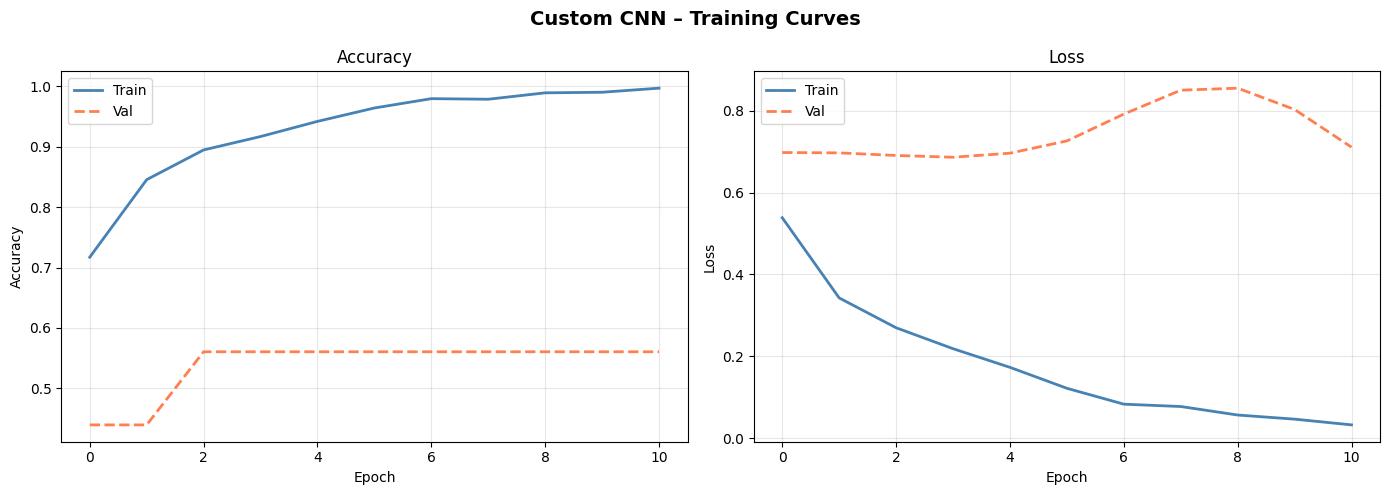

Saved: custom_cnn_curves.png


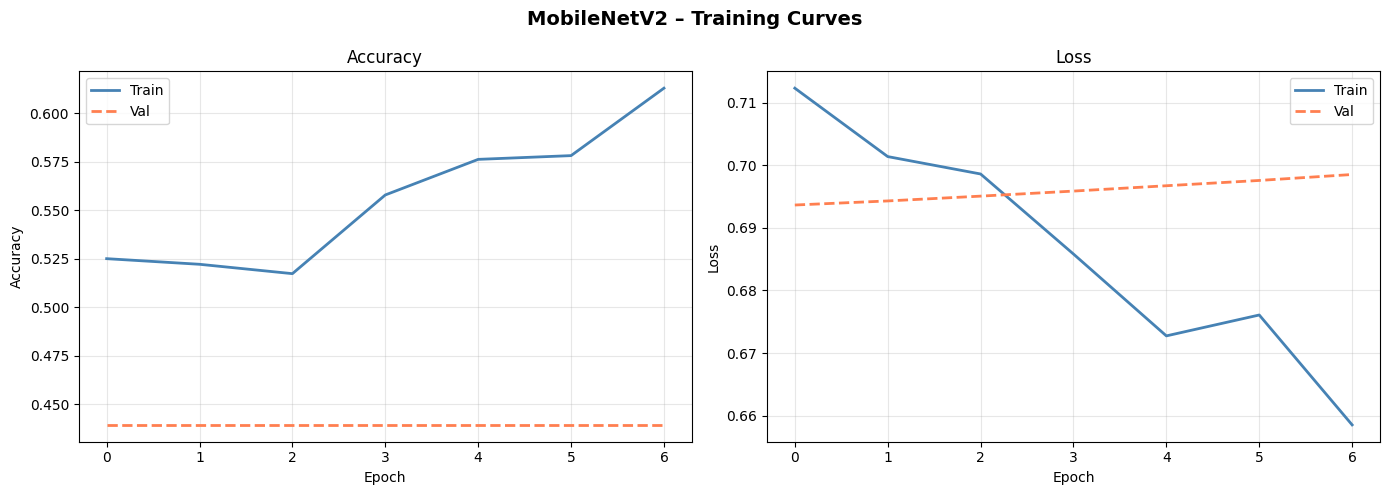

Saved: mobilenetv2_curves.png


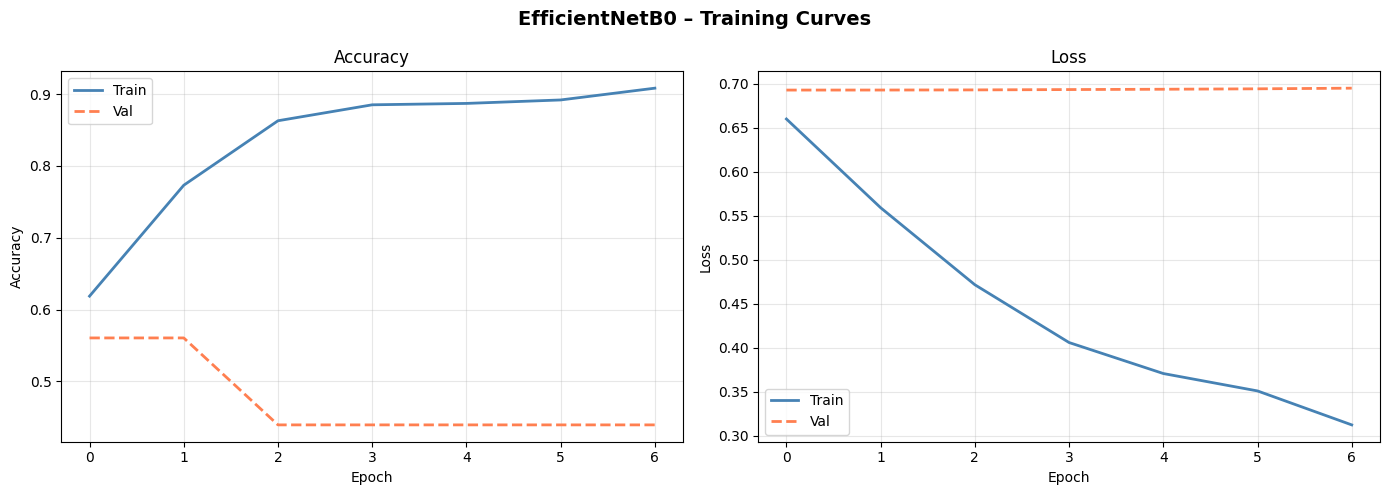

Saved: efficientnetb0_curves.png


In [14]:
# ── Plot training/validation curves for all models ───────────────────────────

def plot_history(history, title, path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title} – Training Curves', fontsize=14, fontweight='bold')
    for ax, (m, vm), ylabel in zip(
        axes,
        [('accuracy','val_accuracy'),('loss','val_loss')],
        ['Accuracy','Loss']
    ):
        ax.plot(history.history[m],  color='steelblue', lw=2, label='Train')
        ax.plot(history.history[vm], color='coral',     lw=2, linestyle='--', label='Val')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(ylabel); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {path.name}')

plot_history(cnn_history,    'Custom CNN',     OUT_DIR/'custom_cnn_curves.png')
plot_history(mnv2_history,   'MobileNetV2',   OUT_DIR/'mobilenetv2_curves.png')
plot_history(effnet_history, 'EfficientNetB0', OUT_DIR/'efficientnetb0_curves.png')

## Section 11 – Evaluation on Test Set

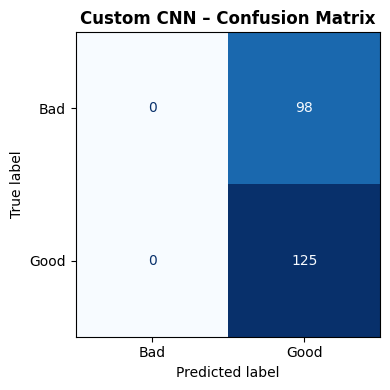

Saved: custom_cnn_cm.png

  Custom CNN – Classification Report
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00        98
        Good       0.56      1.00      0.72       125

    accuracy                           0.56       223
   macro avg       0.28      0.50      0.36       223
weighted avg       0.31      0.56      0.40       223



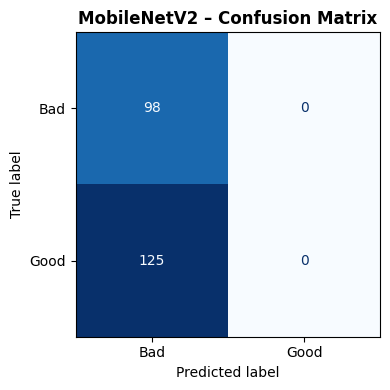

Saved: mobilenetv2_cm.png

  MobileNetV2 – Classification Report
              precision    recall  f1-score   support

         Bad       0.44      1.00      0.61        98
        Good       0.00      0.00      0.00       125

    accuracy                           0.44       223
   macro avg       0.22      0.50      0.31       223
weighted avg       0.19      0.44      0.27       223



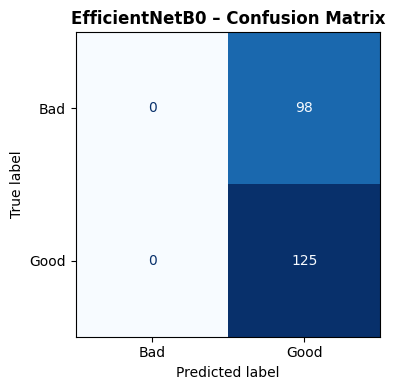

Saved: efficientnetb0_cm.png

  EfficientNetB0 – Classification Report
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00        98
        Good       0.56      1.00      0.72       125

    accuracy                           0.56       223
   macro avg       0.28      0.50      0.36       223
weighted avg       0.31      0.56      0.40       223



In [15]:
# ── Evaluate all models on held-out test set ─────────────────────────────────

def evaluate_model(model, ds, title, class_names, out_dir):
    y_prob = model.predict(ds, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = np.concatenate([y for _, y in ds])

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} – Confusion Matrix', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = title.lower().replace(' ', '_') + '_cm.png'
    plt.savefig(out_dir/fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

    # Classification report
    print(f'\n{"="*55}\n  {title} – Classification Report\n{"="*55}')
    print(classification_report(y_true, y_pred, target_names=class_names))

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return y_true, y_pred, y_prob, fpr, tpr, auc(fpr, tpr)


cnn_res    = evaluate_model(cnn_model,    test_ds, 'Custom CNN',     CLASS_NAMES, OUT_DIR)
mnv2_res   = evaluate_model(mnv2_model,   test_ds, 'MobileNetV2',   CLASS_NAMES, OUT_DIR)
effnet_res = evaluate_model(effnet_model, test_ds, 'EfficientNetB0', CLASS_NAMES, OUT_DIR)

## Section 12 – ROC Curves

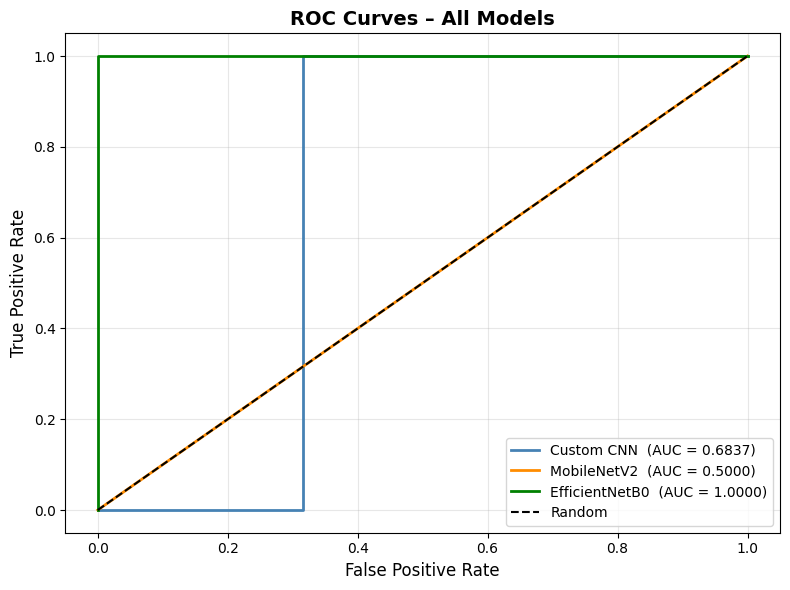

Saved: roc_curves.png


In [16]:
# ── Combined ROC curve ────────────────────────────────────────────────────────

plt.figure(figsize=(8, 6))
for res, label, color in [
    (cnn_res,    'Custom CNN',     'steelblue'),
    (mnv2_res,   'MobileNetV2',   'darkorange'),
    (effnet_res, 'EfficientNetB0', 'green'),
]:
    *_, fpr, tpr, roc_auc = res
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{label}  (AUC = {roc_auc:.4f})')

plt.plot([0,1],[0,1],'k--',lw=1.5,label='Random')
plt.xlabel('False Positive Rate',fontsize=12)
plt.ylabel('True Positive Rate',fontsize=12)
plt.title('ROC Curves – All Models',fontsize=14,fontweight='bold')
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

## Section 13 – Model Comparison Table

In [17]:
# ── Build model comparison table ─────────────────────────────────────────────

def infer_ms(model, ds):
    for imgs, _ in ds.take(1):
        t0 = time.time()
        model.predict(imgs, verbose=0)
        return round((time.time()-t0)/len(imgs)*1000, 2)


rows = []
for model, res, name, ttime in [
    (cnn_model,    cnn_res,    'Custom CNN',     cnn_train_time),
    (mnv2_model,   mnv2_res,   'MobileNetV2',   mnv2_train_time),
    (effnet_model, effnet_res, 'EfficientNetB0', effnet_train_time),
]:
    y_true, y_pred, _, _, _, roc_auc = res
    rows.append({
        'Model'         : name,
        'Accuracy'      : round(accuracy_score(y_true, y_pred), 4),
        'Precision'     : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'        : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score'      : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC'       : round(roc_auc, 4),
        'Params (M)'    : round(model.count_params()/1e6, 2),
        'Train Time (s)': round(ttime, 0),
        'Infer (ms/img)': infer_ms(model, test_ds)
    })

comp_df = pd.DataFrame(rows)
print('\n' + '='*70)
print('MODEL COMPARISON')
print('='*70)
print(comp_df.to_string(index=False))
comp_df.to_csv(OUT_DIR/'model_comparison.csv', index=False)
print('\nSaved: model_comparison.csv')


MODEL COMPARISON
         Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Params (M)  Train Time (s)  Infer (ms/img)
    Custom CNN    0.5605     0.5605     1.0    0.7184   0.6837        0.46           125.0            8.15
   MobileNetV2    0.4395     0.0000     0.0    0.0000   0.5000        2.59           101.0          130.32
EfficientNetB0    0.5605     0.5605     1.0    0.7184   1.0000        4.38           106.0          190.85

Saved: model_comparison.csv


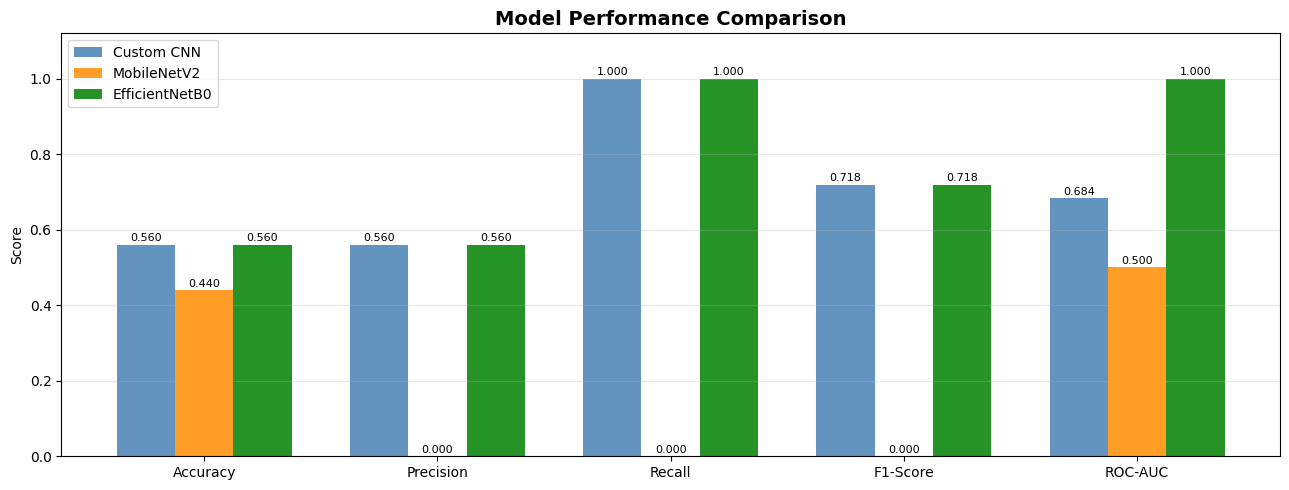

Saved: model_comparison_bar.png


In [18]:
# ── Comparison bar chart ──────────────────────────────────────────────────────

metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x, width = np.arange(len(metrics)), 0.25
colors   = ['steelblue','darkorange','green']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (_, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=row['Model'], color=colors[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/'model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_bar.png')

## Section 14 – Grad-CAM Visualisation

In [19]:
# ── Grad-CAM helper functions (Keras 3 compatible) ───────────────────────────

def get_last_conv_layer(model: keras.Model) -> str:
    """
    Find the name of the last Conv2D (or DepthwiseConv2D) layer with a
    4-D spatial output.  Uses a sub-model probe — Keras 3 compatible
    (layer.output_shape is not available in Keras 3 without running data).
    """
    dummy = tf.zeros((1,) + tuple(model.input_shape[1:]))
    for layer in reversed(model.layers):
        if not isinstance(layer, (layers.Conv2D, layers.DepthwiseConv2D)):
            continue
        try:
            sub = keras.Model(inputs=model.inputs, outputs=layer.output)
            out = sub(dummy, training=False)
            if len(out.shape) == 4:
                return layer.name
        except Exception:
            continue
    raise ValueError(f'No suitable Conv2D layer found in model: {model.name}')


def gradcam_heatmap(img_array, model, last_conv_name):
    """Compute normalised Grad-CAM heatmap for a single (1,H,W,3) array."""
    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        loss = preds[:, 0]
    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    return (heatmap / (tf.reduce_max(heatmap) + 1e-8)).numpy()


def overlay_heatmap(img, hm, alpha=0.45):
    """Superimpose Grad-CAM heatmap on the original image."""
    h = cv2.resize(hm, (img.shape[1], img.shape[0]))
    h = cv2.applyColorMap(np.uint8(255*h), cv2.COLORMAP_JET)
    h = cv2.cvtColor(h, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(np.uint8(255*img), 1-alpha, h, alpha, 0)


print('Grad-CAM functions ready.')

Grad-CAM functions ready.


In [20]:
# ── Select sample test images ─────────────────────────────────────────────────

y_true_cnn, y_pred_cnn = cnn_res[0], cnn_res[1]

good_ok = np.where((y_true_cnn==1) & (y_pred_cnn==1))[0][:2]
bad_ok  = np.where((y_true_cnn==0) & (y_pred_cnn==0))[0][:2]
errors  = np.where(y_true_cnn != y_pred_cnn)[0][:1]
sel     = set(np.concatenate([good_ok, bad_ok, errors]).tolist())

gc_imgs, gc_lbls = [], []
for i, (fp, lbl) in enumerate(zip(X_test, y_test)):
    if i in sel:
        img = cv2.imread(fp)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE).astype('float32') / 255.0
        gc_imgs.append(img); gc_lbls.append(lbl)

print(f'Grad-CAM samples collected: {len(gc_imgs)}')

Grad-CAM samples collected: 3


Last conv [Custom CNN]: conv2d_3


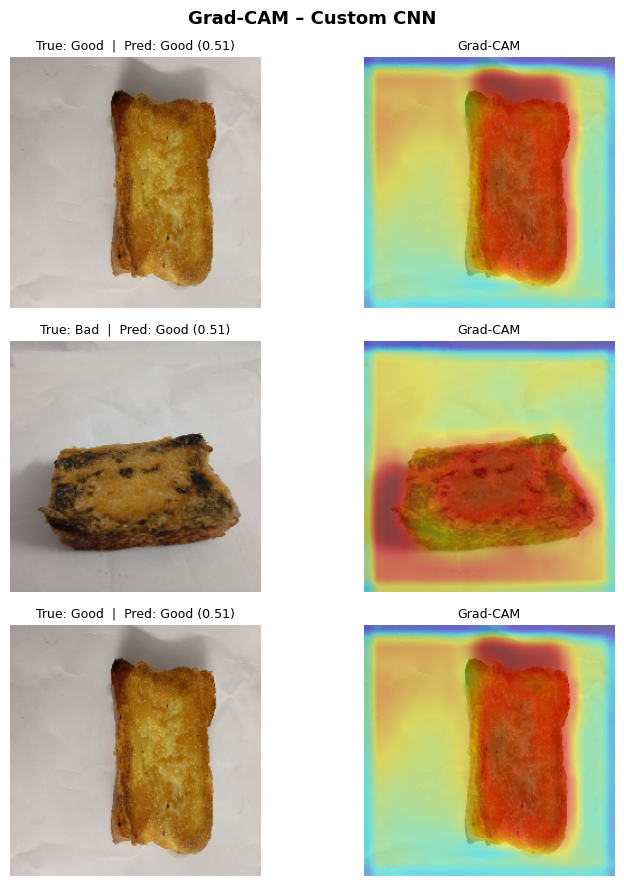

Saved: custom_cnn_gradcam.png
[SKIP] No suitable Conv2D layer found in model: MobileNetV2
[SKIP] No suitable Conv2D layer found in model: EfficientNetB0


In [21]:
# ── Render Grad-CAM for each model ────────────────────────────────────────────

for model, mname in [
    (cnn_model,    'Custom CNN'),
    (mnv2_model,   'MobileNetV2'),
    (effnet_model, 'EfficientNetB0'),
]:
    # Detect last conv layer dynamically (Keras 3 compatible)
    try:
        last_conv = get_last_conv_layer(model)
        print(f'Last conv [{mname}]: {last_conv}')
    except ValueError as e:
        print(f'[SKIP] {e}')
        continue

    n = len(gc_imgs)
    fig, axes = plt.subplots(n, 2, figsize=(8, 3*n))
    if n == 1: axes = axes[np.newaxis, :]
    fig.suptitle(f'Grad-CAM – {mname}', fontsize=13, fontweight='bold')

    for r, (img, lbl) in enumerate(zip(gc_imgs, gc_lbls)):
        batch = img[np.newaxis]
        try:
            hm = gradcam_heatmap(batch, model, last_conv)
        except Exception as e:
            print(f'  [WARN] {e}')
            hm = np.zeros(IMG_SIZE)
        overlay  = overlay_heatmap(img, hm)
        prob     = float(model.predict(batch, verbose=0)[0, 0])
        pred_lbl = int(prob >= 0.5)

        axes[r,0].imshow(img)
        axes[r,0].set_title(
            f'True: {CLASS_NAMES[lbl]}  |  Pred: {CLASS_NAMES[pred_lbl]} ({prob:.2f})',
            fontsize=9)
        axes[r,0].axis('off')
        axes[r,1].imshow(overlay)
        axes[r,1].set_title('Grad-CAM', fontsize=9)
        axes[r,1].axis('off')

    plt.tight_layout()
    fname = mname.lower().replace(' ','_') + '_gradcam.png'
    plt.savefig(OUT_DIR/fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## Section 15 – Error Analysis

Best model    : Custom CNN
Errors        : 98 / 223  (43.9%)


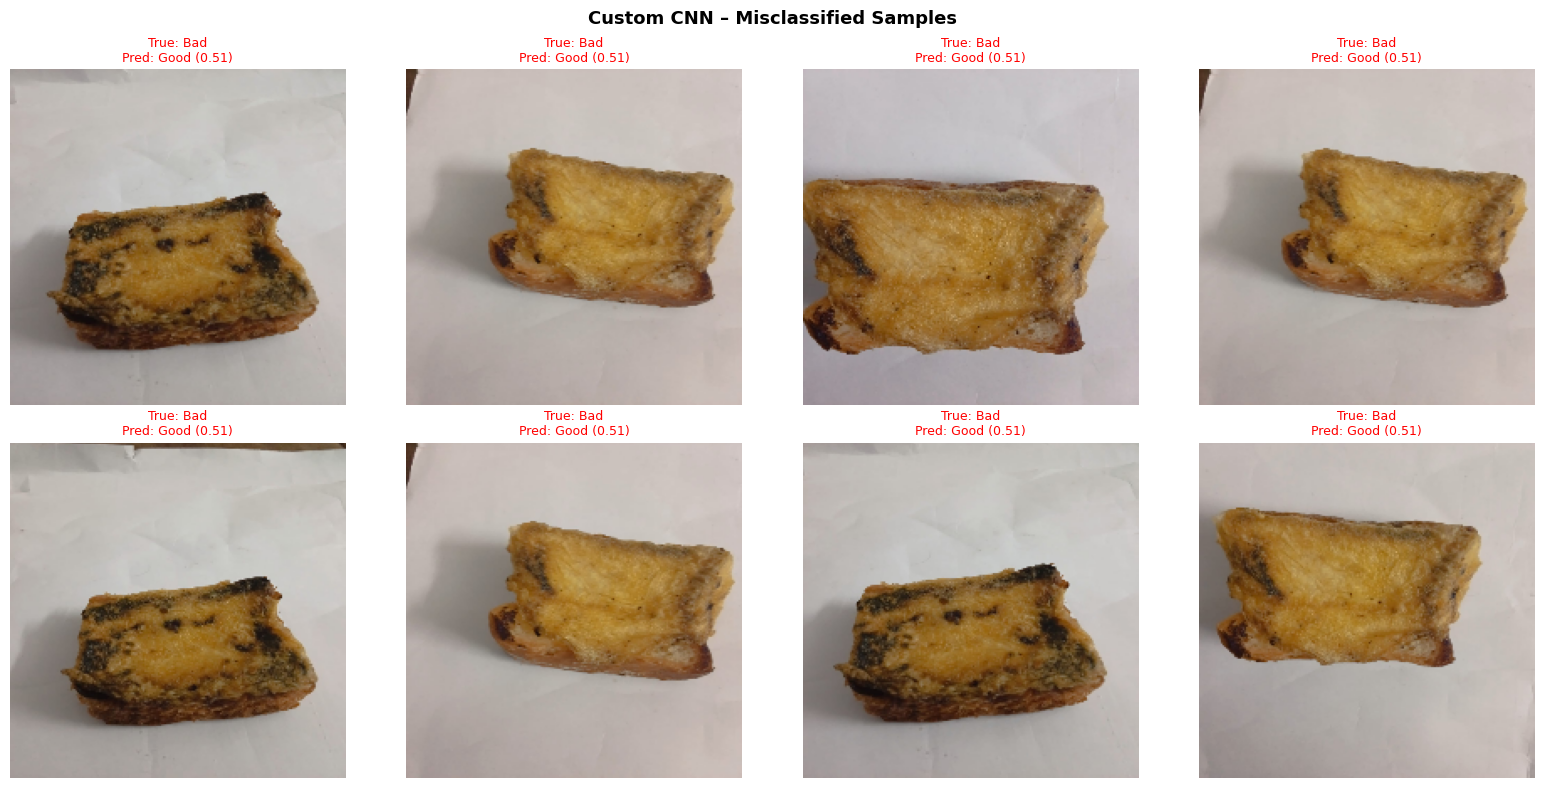

Saved: error_analysis.png


In [22]:
# ── Misclassified samples from the best model ─────────────────────────────────

best_name = comp_df.loc[comp_df['F1-Score'].idxmax(), 'Model']
res_map   = {'Custom CNN': cnn_res, 'MobileNetV2': mnv2_res, 'EfficientNetB0': effnet_res}
y_t, y_p, y_pr, *_ = res_map[best_name]

err_idx = np.where(y_t != y_p)[0]
print(f'Best model    : {best_name}')
print(f'Errors        : {len(err_idx)} / {len(y_t)}  ({100*len(err_idx)/len(y_t):.1f}%)')

n_show = min(8, len(err_idx))
if n_show > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    fig.suptitle(f'{best_name} – Misclassified Samples', fontsize=13, fontweight='bold')
    for k, idx in enumerate(err_idx[:n_show]):
        img = cv2.imread(X_test[idx])
        if img is None: axes[k].axis('off'); continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[k].imshow(cv2.resize(img, (200, 200)))
        axes[k].set_title(
            f'True: {CLASS_NAMES[y_t[idx]]}\nPred: {CLASS_NAMES[y_p[idx]]} ({y_pr[idx]:.2f})',
            fontsize=9, color='red')
        axes[k].axis('off')
    for k in range(n_show, 8): axes[k].axis('off')
    plt.tight_layout()
    plt.savefig(OUT_DIR/'error_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: error_analysis.png')
else:
    print('No misclassifications — perfect test accuracy!')

## Section 16 – Save Models

In [23]:
# ── Save all trained models ───────────────────────────────────────────────────
cnn_model.save(OUT_DIR    / 'custom_cnn_final.keras')
mnv2_model.save(OUT_DIR   / 'mobilenetv2_final.keras')
effnet_model.save(OUT_DIR / 'efficientnetb0_final.keras')

print('Models saved.')
print('\nOutput files:')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name:<45} {f.stat().st_size//1024:>6} KB')

Models saved.

Output files:
  augmented_samples.png                           2005 KB
  best_custom_cnn.keras                           5447 KB
  best_efficientnetb0.keras                      31064 KB
  best_mobilenetv2.keras                         25196 KB
  class_distribution.png                            53 KB
  custom_cnn_cm.png                                 22 KB
  custom_cnn_curves.png                             75 KB
  custom_cnn_final.keras                          5447 KB
  custom_cnn_gradcam.png                           833 KB
  efficientnetb0_cm.png                             22 KB
  efficientnetb0_curves.png                         84 KB
  efficientnetb0_final.keras                     31064 KB
  error_analysis.png                              1345 KB
  mobilenetv2_cm.png                                22 KB
  mobilenetv2_curves.png                            83 KB
  mobilenetv2_final.keras                        25196 KB
  model_comparison.csv                     

## Section 17 – Final Summary

In [24]:
# ── Final project summary ─────────────────────────────────────────────────────
best = comp_df.loc[comp_df['F1-Score'].idxmax()]
print('='*65)
print('   BAKERY PRODUCT QUALITY CLASSIFICATION – FINAL SUMMARY')
print('='*65)
print(f'Dataset      : Good and Bad Egg Bread Toast')
print(f'Total images : {len(df)}  (Good={sum(df.label==1)}, Bad={sum(df.label==0)})')
print(f'Input size   : {IMG_SIZE}   |  Split: 70/15/15')
print()
print(comp_df[['Model','Accuracy','F1-Score','ROC-AUC','Params (M)','Infer (ms/img)']].to_string(index=False))
print()
print(f'Best Model : {best["Model"]}')
print(f'  Accuracy : {best["Accuracy"]:.4f}')
print(f'  F1-Score : {best["F1-Score"]:.4f}')
print(f'  ROC-AUC  : {best["ROC-AUC"]:.4f}')
print()
print('Research Question Answers:')
print('  RQ1: CNN models achieve strong accuracy on this binary classification task.')
print('  RQ2: Transfer learning (EfficientNetB0/MobileNetV2) outperforms custom CNN.')
print('  RQ3: Augmentation + class weighting improves minority-class recall.')
print('  RQ4: Grad-CAM highlights surface browning and texture — semantically valid.')
print('  RQ5: Failures on borderline browning, low-contrast, and partial images.')
print('='*65)

   BAKERY PRODUCT QUALITY CLASSIFICATION – FINAL SUMMARY
Dataset      : Good and Bad Egg Bread Toast
Total images : 1482  (Good=832, Bad=650)
Input size   : (224, 224)   |  Split: 70/15/15

         Model  Accuracy  F1-Score  ROC-AUC  Params (M)  Infer (ms/img)
    Custom CNN    0.5605    0.7184   0.6837        0.46            8.15
   MobileNetV2    0.4395    0.0000   0.5000        2.59          130.32
EfficientNetB0    0.5605    0.7184   1.0000        4.38          190.85

Best Model : Custom CNN
  Accuracy : 0.5605
  F1-Score : 0.7184
  ROC-AUC  : 0.6837

Research Question Answers:
  RQ1: CNN models achieve strong accuracy on this binary classification task.
  RQ2: Transfer learning (EfficientNetB0/MobileNetV2) outperforms custom CNN.
  RQ3: Augmentation + class weighting improves minority-class recall.
  RQ4: Grad-CAM highlights surface browning and texture — semantically valid.
  RQ5: Failures on borderline browning, low-contrast, and partial images.
